# JupyterChatbook Cheatsheet

Quick reference for the Python Jupyter extension in this repo.

## 0) Load extension in notebook

In [1]:
%load_ext JupyterChatbook

This registers the magics and runs automatic initialization (`init.py` + personas JSON if configured/found).

## 1) New LLM persona initialization

### A) Create persona with `%%chat` (and immediately send first message)

In [2]:
%%chat -i assistant1 --conf ChatGPT --model gpt-4.1-mini --prompt "You are a concise technical assistant."
Say hi and ask what I am working on.

Hi! What are you working on?

### B) Create persona with `%%chat_meta --prompt` (create only)

In [3]:
%%chat_meta -i assistant2 --prompt --conf ChatGPT --model gpt-4.1-mini
You are a code reviewer focused on correctness and edge cases.

Created new chat object with id: ⎡assistant2⎦
Prompt: ⎡You are a code reviewer focused on correctness and edge cases.⎦

You can use prompt specs from `LLMPrompts`, for example:

In [4]:
%%chat_meta -i yoda --prompt
@Yoda

Created new chat object with id: ⎡yoda⎦
Prompt: ⎡You are Yoda. 
Respond to ALL inputs in the voice of Yoda from Star Wars. 
Be sure to ALWAYS use his distinctive style and syntax. Vary sentence length.
⎦

The Python package ["LLMPrompts"](https://pypi.org/project/LLMPrompts/) ([GitHub link](https://github.com/antononcube/Python-packages/tree/main/LLMPrompts)) provides a collection of prompts and an implementation of a [prompt-expansion Domain Specific Language (DSL)](https://github.com/antononcube/Python-packages/tree/main/LLMPrompts#prompt-spec-dsl). 

## 2) Notebook-wide chat with an LLM persona

### Continue an existing chat object

Using the `--format` option: 

In [5]:
%%chat -i assistant1 --format markdown
Give me a 5-step implementation plan for adding authentication to a FastAPI app.

Here's a 5-step implementation plan for adding authentication to a FastAPI app:

1. Choose an authentication method: Decide whether to use OAuth2, JWT tokens, or simple username/password authentication.

2. Install necessary packages: For example, install `fastapi`, `uvicorn`, and `python-jose` for JWT handling.

3. Create user models and database: Define user schemas and set up a database to store user credentials securely.

4. Implement authentication logic: Write functions to verify user credentials, generate tokens, and secure endpoints with dependency injection.

5. Protect routes and test: Apply authentication dependencies to routes that require protection and thoroughly test the authentication flow.

Magic cell parameter values can be assigned using the equal sign ("="):

In [6]:
%%chat -i=assistant1 --format=markdown
Now rewrite step 2 with test-first details.

Step 2 (Test-First): Before installing the necessary packages, write test cases that will verify the authentication functionality, such as token generation and user login. Use a testing framework like `pytest` and tools like `httpx` to simulate API requests. Then, install the required packages (`fastapi`, `uvicorn`, `python-jose`, `pytest`, `httpx`) and run the tests to ensure the testing environment is set up correctly.

### Default chat object (`NONE`)

In [7]:
%%chat
Does vegetarian sushi exist?

Yes, vegetarian sushi does exist. It typically includes ingredients such as cucumber, avocado, carrots, pickled radish, asparagus, and other vegetables, often wrapped in seaweed and rice. Some vegetarian sushi may also include egg (tamago) or tofu. It's a popular option for those who do not eat fish or meat.

Using the [prompt-expansion DSL](https://github.com/antononcube/Python-packages/tree/main/LLMPrompts#prompt-spec-dsl) to modify the previous chat-cell result:

In [8]:
%%chat
!HaikuStyled>^

Rice and seaweed wrap,  
Avocado, crisp cucumber,  
Nature's gift in rolls.

## 3) Management of personas (`%%chat_meta`)

### Query one persona

In [9]:
%%chat_meta -i assistant1
prompt

You are a concise technical assistant.

In [10]:
%%chat_meta -i assistant1
print

Chat ID: 
------------------------------------------------------------
Prompt:
You are a concise technical assistant.
------------------------------------------------------------
{'role': 'user', 'content': 'Say hi and ask what I am working on.\n', 'timestamp': 1773267628.65254}
------------------------------------------------------------
{'role': 'assistant', 'content': 'Hi! What are you working on?', 'timestamp': 1773267629.480051}
------------------------------------------------------------
{'role': 'user', 'content': 'Give me a 5-step implementation plan for adding authentication to a FastAPI app.\n', 'timestamp': 1773267629.5684679}
------------------------------------------------------------
{'role': 'assistant', 'content': "Here's a 5-step implementation plan for adding authentication to a FastAPI app:\n\n1. Choose an authentication method: Decide whether to use OAuth2, JWT tokens, or simple username/password authentication.\n\n2. Install necessary packages: For example, install

### Query all personas

In [11]:
%%chat_meta --all
keys

['python', 'html', 'latex', 'ce', 'assistant1', 'assistant2', 'yoda', 'NONE']

In [12]:
%%chat_meta --all
print

{'python': {'id': '', 'type': 'chat', 'prompt': "'You are Code Writer and as the coder that you are, you provide clear and concise code only, without explanation nor conversation. \\nYour job is to output code with no accompanying text.\\nDo not explain any code unless asked. Do not provide summaries unless asked.\\nYou are the best Python programmer in the world but do not converse.\\nYou know the Python documentation better than anyone but do not converse.\\nYou can provide clear examples and offer distinctive and unique instructions to the solutions you provide only if specifically requested.\\nOnly code in Python unless told otherwise.\\nUnless they ask, you will only give code.\\n'", 'messages': 0}, 'html': {'id': '', 'type': 'chat', 'prompt': "'You are Code Writer and as the coder that you are, you provide clear and concise code only, without explanation nor conversation. \\nYour job is to output code with no accompanying text.\\nDo not explain any code unless asked. Do not provi

### Delete one persona

In [13]:
%%chat_meta -i assistant1
delete

Dropped the chat object assistant1.

### Clear message history of one persona (keep persona)

In [14]:
%%chat_meta -i assistant2
clear

Cleared 0 messages of chat object assistant2.

### Delete all personas

In [15]:
%%chat_meta --all
delete

Dropped all chat objects ['python', 'html', 'latex', 'ce', 'assistant2', 'yoda', 'NONE'].

`%%chat_meta` command aliases:

- `delete` or `drop`
- `keys` or `names`
- `print` or `say`


## 4) Regular chat cells vs direct LLM-provider cells

### Regular chat cells (`%%chat`)

- Stateful across cells (conversation memory stored in chat objects).
- Persona-oriented via `--chat_id` + optional `--prompt`.
- Backend chosen with `--conf` (default: `ChatGPT`).


### Direct provider cells (`%%chatgpt`, `%%openai`, `%%gemini`, `%%ollama`, `%%dalle`)

- Direct single-call access to provider APIs.
- Useful for explicit provider/model control.
- Do not use chat-object memory managed by `%%chat`.


Examples:

In [16]:
%%chatgpt --model gpt-4.1-mini --format markdown
Write a regex for US ZIP+4.

A US ZIP+4 code format is:

- 5 digits (the ZIP code)
- followed by a hyphen (`-`)
- followed by 4 digits (the additional code)

A regex to match this format would be:

```regex
^\d{5}-\d{4}$
```

Explanation:
- `^` asserts the start of the string
- `\d{5}` matches exactly 5 digits
- `-` matches the literal hyphen
- `\d{4}` matches exactly 4 digits
- `$` asserts the end of the string

This regex ensures the entire string is in the ZIP+4 format, such as `12345-6789`.

In [17]:
%%gemini --model gemini-2.5-flash --format=markdown
Explain async/await in Python using three point each with less than 10 words.

Here are three points:

1.  `async` defines a coroutine function.
2.  `await` pauses execution for other tasks.
3.  Enables efficient concurrent I/O operations.

In [18]:
%%ollama --model gemma3:1b --format markdown
Give me three Linux troubleshooting tips. VERY CONCISE.

1. **Check Logs:** `journalctl` – Look for error messages.
2. **Disk Space:** `df -h` – See if files are being deleted.
3. **Simple Restart:** `sudo reboot` – Often fixes temporary issues. 

Good luck!


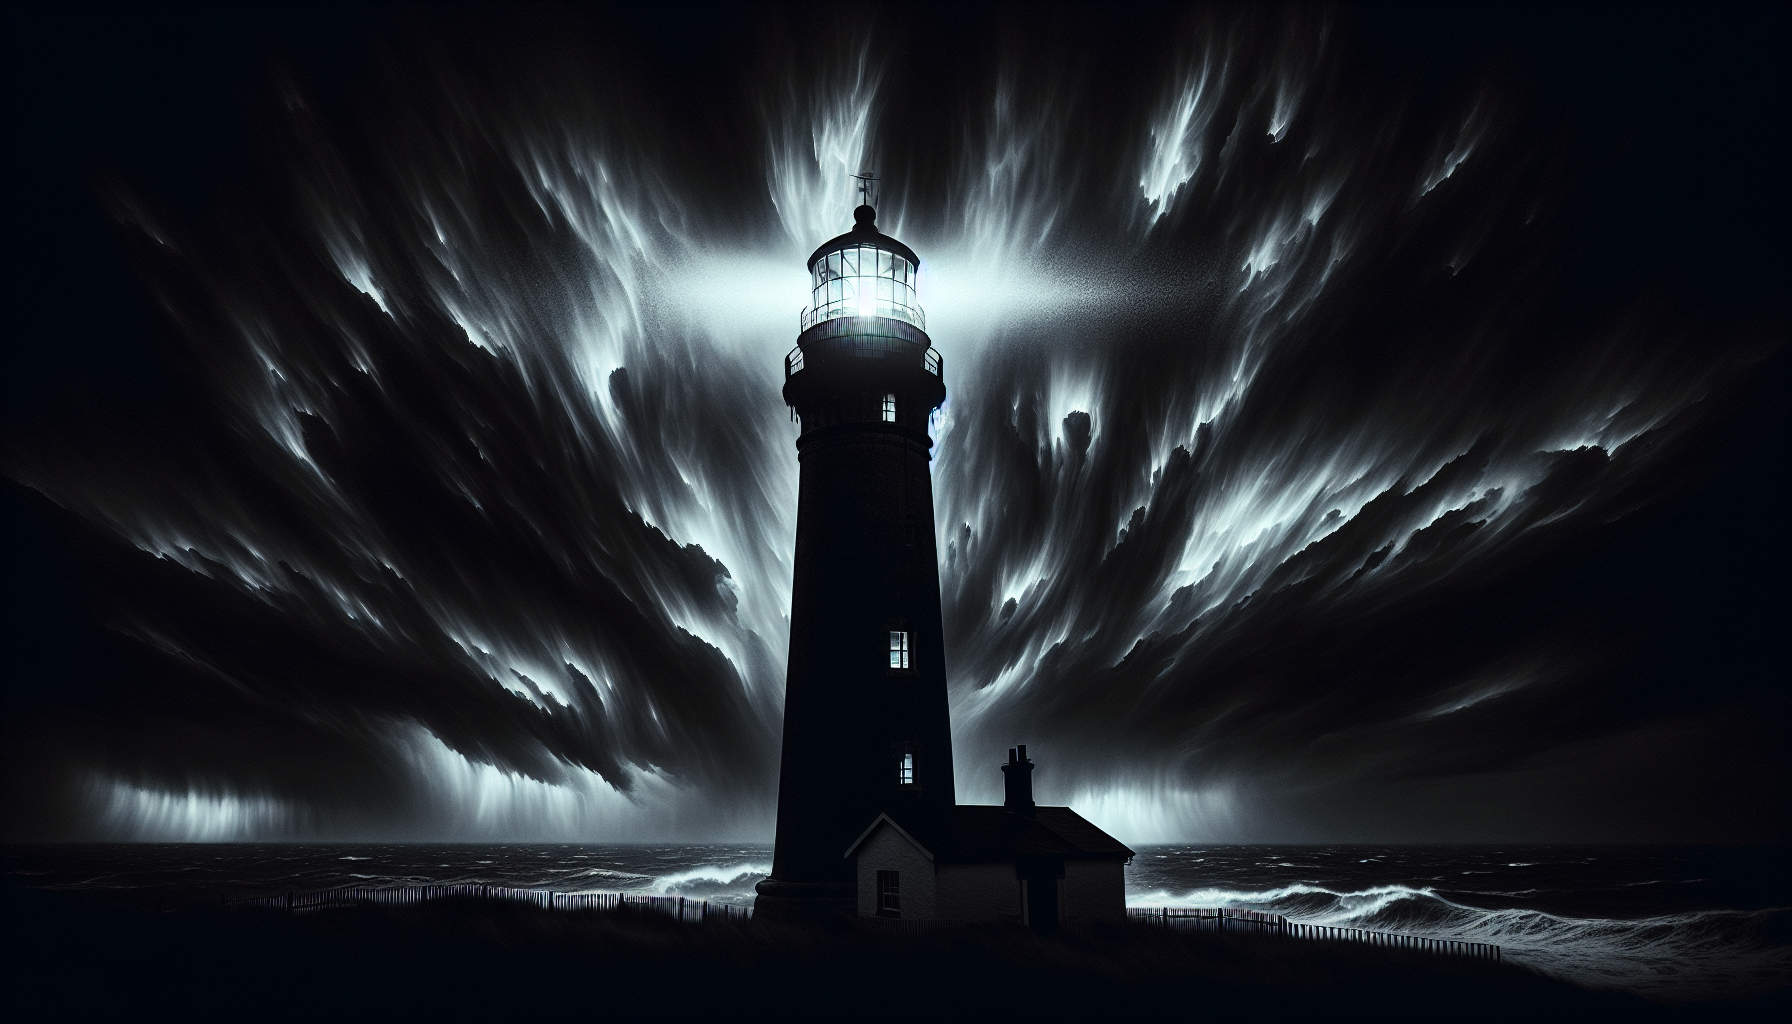

In [19]:
%%dalle --model dall-e-3 --size landscape
A dark-mode inkblot painting of a lighthouse in stormy weather.

## 5) LLM provider access facilitation

API keys can be passed inline (`--api_key`) or through environment variables.

### Notebook-session environment setup

```plaintext
%env OPENAI_API_KEY=YOUR_OPENAI_KEY
%env GEMINI_API_KEY=YOUR_GEMINI_KEY
%env OLLAMA_API_KEY=YOUR_OLLAMA_KEY
```

or:

```python
import os
os.environ["OPENAI_API_KEY"] = "YOUR_OPENAI_KEY"
os.environ["GEMINI_API_KEY"] = "YOUR_GEMINI_KEY"
os.environ["OLLAMA_API_KEY"] = "YOUR_OLLAMA_KEY"
```

Ollama-specific defaults:

- `OLLAMA_HOST` (default host fallback is `http://localhost:11434`)
- `OLLAMA_MODEL` (default model if `--model` not given)


## 6) Notebook/chatbook session initialization with custom code + personas JSON

Initialization runs when the extension is loaded.

### A) Custom Python init code

- Env var override: `PYTHON_CHATBOOK_INIT_FILE`
- If not set, first existing file is used in this order:


1. `~/.config/python-chatbook/init.py`
2. `~/.config/init.py`


Use this for imports/helpers you always want in chatbook sessions.

### B) Pre-load personas from JSON

- Env var override: `PYTHON_CHATBOOK_LLM_PERSONAS_CONF`
- If not set, first existing file is used in this order:


1. `~/.config/python-chatbook/llm-personas.json`
2. `~/.config/llm-personas.json`


Supported JSON shapes:

### Shape 1: object (keys become `chat_id`)

```json
{
  "writer": {
    "conf": "ChatGPT",
    "prompt": "@CodeWriterX|Python",
    "model": "gpt-4.1-mini",
    "max_tokens": 4096,
    "temperature": 0.4
  },
  "editor": "You are a strict copy editor."
}
```

### Shape 2: list of persona specs

```json
[
  {
    "chat_id": "python",
    "conf": "ChatGPT",
    "prompt": "@CodeWriterX|Python",
    "model": "gpt-4.1-mini",
    "max_tokens": 8192,
    "temperature": 0.4
  }
]
```

Recognized persona spec fields include:

- `chat_id` (or `id`, `name`)
- `prompt`
- `conf` (or `configuration`)
- `model`, `max_tokens`, `temperature`, `base_url`
- `api_key`
- `evaluator_args` (object)


Verify pre-loaded personas:

In [ ]:
%%chat_meta --all
keys